# Phase1

In [32]:
import numpy as np
import pandas as pd

In [33]:
df = pd.read_pickle('../submission_data.pkl')

In [34]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1618, 107)

Columns:
Index(['Sno', 'Lecture', 'StudentNo', 'Total_Characters', 'Total_Words',
       'Submission_Time', 'Submission_Delay', 'x_01', 'x_02', 'x_03',
       ...
       'x_91', 'x_92', 'x_93', 'x_94', 'x_95', 'x_96', 'x_97', 'x_98', 'x_99',
       'x_100'],
      dtype='str', length=107)

Data Types:
Sno                   int64
Lecture               int64
StudentNo             int64
Total_Characters      int64
Total_Words           int64
                     ...   
x_96                float64
x_97                float64
x_98                float64
x_99                float64
x_100               float64
Length: 107, dtype: object

Missing Values:
Sno                 0
Lecture             0
StudentNo           0
Total_Characters    0
Total_Words         0
                   ..
x_96                0
x_97                0
x_98                0
x_99                0
x_100               0
Length: 107, dtype: int64


In [35]:
df["target"] = np.where(df["Submission_Delay"] > 0, 1, 0)

C:\Users\yaswa\AppData\Local\Temp\ipykernel_26204\3044006979.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = np.where(df["Submission_Delay"] > 0, 1, 0)


In [36]:
df.drop(columns=["Submission_Delay"], inplace=True)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()
feature_columns = df.select_dtypes(include=["number"]).columns.drop("target")
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# Phase2

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
correlations = df.corr()["target"].drop("target")
print(correlations)

Sno                 0.035988
Lecture            -0.020825
StudentNo           0.008001
Total_Characters   -0.053349
Total_Words        -0.055027
                      ...   
x_96               -0.021038
x_97                0.005254
x_98               -0.023842
x_99               -0.007503
x_100               0.039395
Name: target, Length: 106, dtype: float64


In [41]:
top15_features = correlations.abs().sort_values(ascending=False).head(15)
print(top15_features)

x_04                0.065493
x_05                0.060733
x_54                0.057554
Total_Words         0.055027
Total_Characters    0.053349
x_74                0.047948
x_84                0.046002
x_19                0.044380
x_52                0.043613
x_25                0.039566
x_100               0.039395
x_38                0.036348
Sno                 0.035988
x_02                0.035862
x_86                0.035243
Name: target, dtype: float64


In [42]:
top15_feature_names = top15_features.index.tolist()
print(top15_feature_names)

['x_04', 'x_05', 'x_54', 'Total_Words', 'Total_Characters', 'x_74', 'x_84', 'x_19', 'x_52', 'x_25', 'x_100', 'x_38', 'Sno', 'x_02', 'x_86']


In [43]:
top15_corr = df[top15_feature_names].corr()

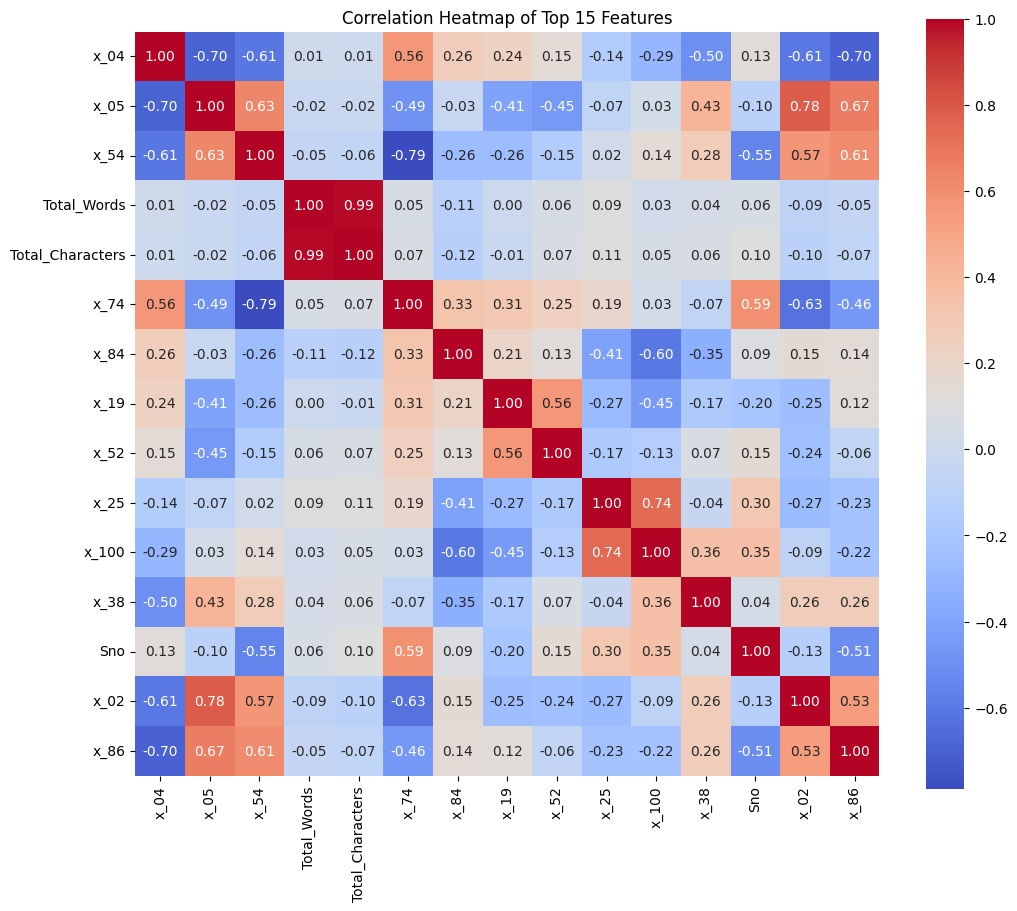

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(top15_corr,annot=True,cmap="coolwarm",fmt=".2f",square=True)
plt.title("Correlation Heatmap of Top 15 Features")
plt.show()

# Phase3

In [45]:
from sklearn.manifold import TSNE
import umap

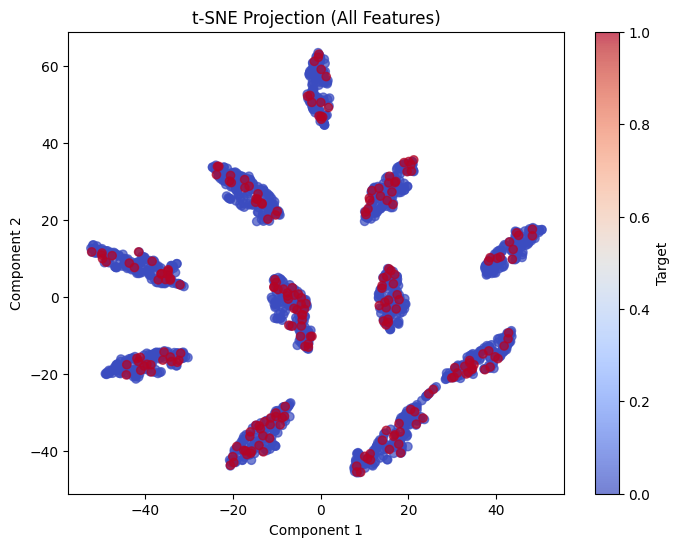

In [46]:
X = df.drop(columns=["target", "Submission_Time"])
y = df["target"]
tsne = TSNE(n_components=2,random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0],X_tsne[:, 1],c=y,cmap="coolwarm",alpha=0.7)

plt.title("t-SNE Projection (All Features)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Target")
plt.show()

d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


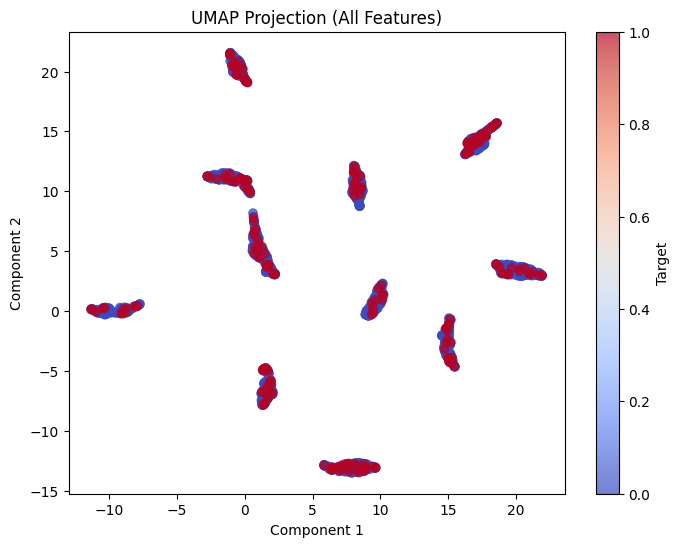

In [47]:
umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("UMAP Projection (All Features)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Target")
plt.show()

d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


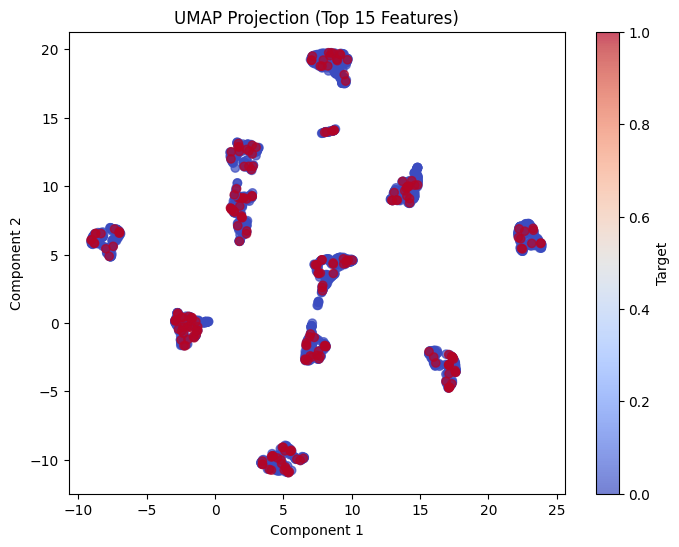

In [48]:
X_top15 = df[top15_feature_names]
umap_top15 = umap.UMAP(
    n_components=2,
    random_state=42
)
X_top15_umap = umap_top15.fit_transform(X_top15)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_top15_umap[:, 0],
    X_top15_umap[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("UMAP Projection (Top 15 Features)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Target")
plt.show()

# Part3

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [50]:
# Split
X = df[top15_feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
# Regression Logistic
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

In [52]:
#SVC
svc_model = SVC(
    probability=True,
    random_state=42
)

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)
svc_prob = svc_model.predict_proba(X_test)[:, 1]

In [53]:
# Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [54]:
# Evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 40)

    print(classification_report(y_true, y_pred))

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))

In [55]:
# Evaluate all models
evaluate_model("Logistic Regression",y_test,log_pred,log_prob)

evaluate_model("Support Vector Machine",y_test,svc_pred,svc_prob)

evaluate_model("Random Forest",y_test,rf_pred,rf_prob)


Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

Accuracy : 0.8765432098765432
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.7063380281690141

Support Vector Machine
----------------------------------------
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

Accuracy : 0.8765432098765432
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.8950704225352113

Random F

d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

In [56]:
#Comparision table
results = {
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, svc_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, svc_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, svc_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, svc_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, svc_prob),
        roc_auc_score(y_test, rf_prob)
    ]
}

results_df = pd.DataFrame(results)

results_df

d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.876543,0.000000,0.000,0.000000,0.706338
1,Support Vector Machine,0.876543,0.000000,0.000,0.000000,0.895070
2,Random Forest,0.925926,0.944444,0.425,0.586207,0.961620
